Create Model 1 using Tensorflow

In [1]:
import kagglehub
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
import pandas as pd
import PIL

from tensorflow import keras
from tensorflow.keras import layers

datasetPath = kagglehub.dataset_download("ongshujian/real-and-fake-pokemon-cards")

def build_tensor_deep_model(hp):
    base_filters = hp.Choice("base_filter", [16, 32]) # for feature extraction
    dense_units = hp.Choice("dense_units", [64, 128]) # for feature classification 
    activeFunctions = hp.Choice("activation", ["relu", "sigmoid", "tanh", "elu"]) # activation function.
    model = keras.models.Sequential([
        layers.Conv2D(base_filters, 3, padding='same', activation=activeFunctions),
        layers.MaxPooling2D(),
        layers.Conv2D(base_filters * 2, 3, padding='same', activation=activeFunctions),
        layers.MaxPooling2D(),
        layers.Conv2D(base_filters * 4, 3, padding='same', activation=activeFunctions),
        layers.MaxPooling2D(),
        layers.Flatten(),
        layers.Dense(dense_units, activation=activeFunctions),
        layers.Dense(2)
    ])
    model.compile(optimizer='adam', loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True), metrics=['accuracy'])
    return model



Using Colab cache for faster access to the 'real-and-fake-pokemon-cards' dataset.


Process the data and split into training and validation sets. Use Tensorflows function to work.

Trial 16 Complete [00h 00m 40s]
val_accuracy: 0.9333333373069763

Best val_accuracy So Far: 1.0
Total elapsed time: 00h 07m 30s
Epoch 1/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 6s 340ms/step - accuracy: 0.5872 - loss: 1.1942 - val_accuracy: 0.6667 - val_loss: 0.6112
Epoch 2/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 52ms/step - accuracy: 0.7081 - loss: 0.5704 - val_accuracy: 0.7333 - val_loss: 0.5252
Epoch 3/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - accuracy: 0.7651 - loss: 0.5035 - val_accuracy: 0.8267 - val_loss: 0.4491
Epoch 4/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step - accuracy: 0.7785 - loss: 0.4649 - val_accuracy: 0.8267 - val_loss: 0.3986
Epoch 5/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - accuracy: 0.8389 - loss: 0.3752 - val_accuracy: 0.8667 - val_loss: 0.3457
Epoch 6/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.8691 - loss: 0.2751 - val_accuracy: 0.8933 - val_loss: 0.2573
Epoch 7/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.9262 - loss: 0.1835 - val_accuracy: 0.9333 -

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 224, 224, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 112, 112, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 112, 112, 32)   │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 56, 56, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 56, 56, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 28, 28, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 50176)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │     3,211,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,705,128 (37.02 MB)

 Trainable params: 3,235,042 (12.34 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 6,470,086 (24.68 MB)

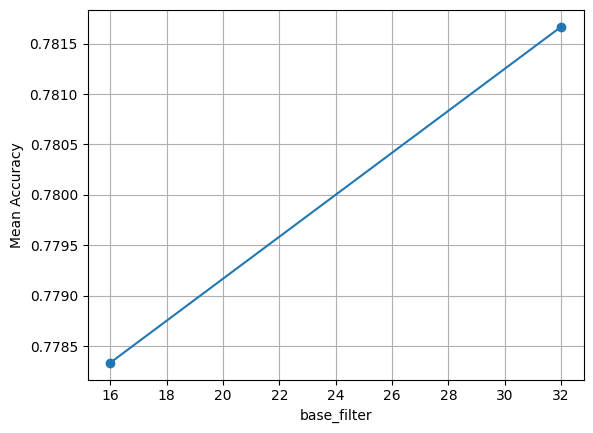

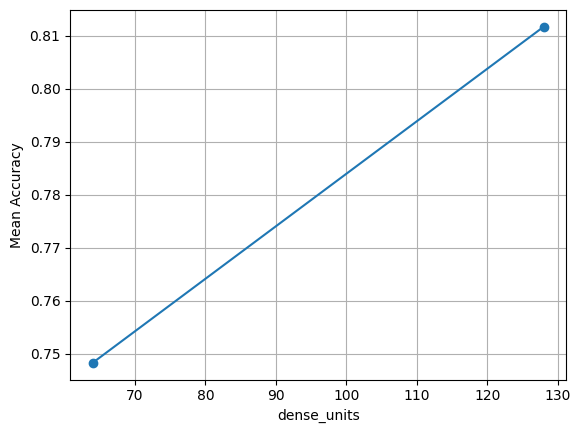

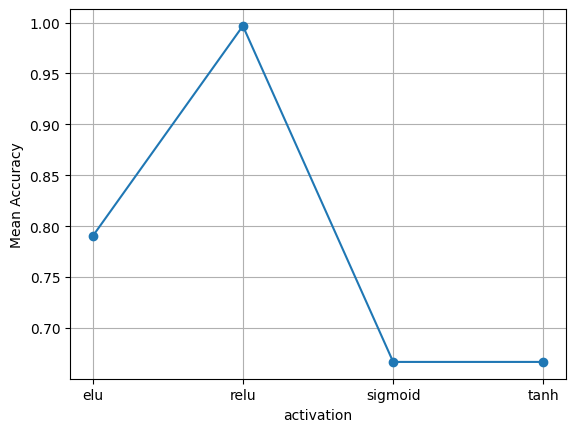

In [2]:
#install keras tuner so we can tune hypermodels in Tensorflow
%pip install -q -U keras-tuner

import os
#we'll use this tool for training validation split for relative ease of use
from sklearn.model_selection import train_test_split, RandomizedSearchCV
import keras_tuner as kt

df = pd.read_csv(f"{datasetPath}/train_labels.csv") 
#shuffle dataset because the original dataset is ordered. We want to keep 
photoID_training, photoID_valid, classify_training, classify_valid = train_test_split(
    df["id"], df["label"],
    test_size= .2,
    stratify = df["label"],
    random_state=42
)


def processThroughImages(imagesCollection, labels, stage):
    imagesArray = []
    labelToReturn= []
    # Images 1 - 298 in our dataset will be our training data. Rest will be testing
    for imageID, label in zip(imagesCollection, labels):
        imageToProcessFilePath = os.path.join(datasetPath, stage, f"{imageID}.JPG")
        
        if not os.path.exists(imageToProcessFilePath):
            print(f"Missing: {imageToProcessFilePath}")
            continue

        imageToProcess = keras.utils.img_to_array(keras.utils.load_img(imageToProcessFilePath, target_size=[224,224]))
        
        imagesArray.append(imageToProcess)
        labelToReturn.append(label)
    
    
    return np.array(imagesArray), np.array(labelToReturn)

trainingImagesArray, trainingClassifyArray = processThroughImages(photoID_training, classify_training, "train")
validationImagesArray, validationClassifyArray = processThroughImages(photoID_valid, classify_valid, "train")

#normalize for model's ease
trainingImagesArray /= 255.0
validationImagesArray /= 255.0

# hypertune parameters with model 1 and see what we can do
model1Tuner = kt.GridSearch(
    build_tensor_deep_model,
    objective="val_accuracy",
    max_trials=None,
    directory="fakeCardTensorflowLogs",
    project_name="pokemonFakeCardClassifierDeepModel"
)

model1Tuner.search(
    trainingImagesArray, trainingClassifyArray,
    epochs = 30,
    validation_data=(validationImagesArray, validationClassifyArray)
)

# display our results of our tuning here. 
def showHyperPlot(param: str, results, groupBy="mean_test_score"):
  toPlot = results.groupby(param)[groupBy].mean()
  plt.figure()
  plt.plot(toPlot.index, toPlot.values, marker="o")
  plt.xlabel(param)
  plt.ylabel("Mean Accuracy")
  plt.grid(True)
  plt.show()




# rebuild with best hyperparameters and get our final tuned model
model1 = model1Tuner.hypermodel.build(model1Tuner.get_best_hyperparameters(1)[0])

model1.fit(
    trainingImagesArray, trainingClassifyArray, 
    epochs = 30,
    validation_data=(validationImagesArray, validationClassifyArray)
)

model1Results = pd.DataFrame([
    {**t.hyperparameters.values, "score": t.score} for t in model1Tuner.oracle.trials.values() if t.score is not None
])
print(model1Results.columns)
print(model1Results.head())


model1.summary()
showHyperPlot("base_filter", model1Results, "score")
showHyperPlot("dense_units", model1Results, "score")
showHyperPlot("activation", model1Results, "score")

Let's try creation a second model and see which one is more accurate. We're going to build a Tensorflow shallow learning model (even if it is not recommended for image processing and classification) and see if it could ever beat it.

Trial 8 Complete [00h 00m 13s]
val_accuracy: 0.6666666865348816

Best val_accuracy So Far: 0.6666666865348816
Total elapsed time: 00h 01m 54s
Epoch 1/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 201ms/step - accuracy: 0.4933 - loss: 30.1468 - val_accuracy: 0.3333 - val_loss: 0.6936
Epoch 2/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.4027 - loss: 0.6933 - val_accuracy: 0.6667 - val_loss: 0.6926
Epoch 3/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.6711 - loss: 0.6918 - val_accuracy: 0.6667 - val_loss: 0.6906
Epoch 4/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.6711 - loss: 0.6898 - val_accuracy: 0.6667 - val_loss: 0.6887
Epoch 5/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.6711 - loss: 0.6877 - val_accuracy: 0.6667 - val_loss: 0.6867
Epoch 6/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.6711 - loss: 0.6856 - val_accuracy: 0.6667 - val_loss: 0.6845
Epoch 7/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.6711 - loss: 0.6833 - val_acc

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 150528)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │     9,633,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 28,901,960 (110.25 MB)

 Trainable params: 9,633,986 (36.75 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 19,267,974 (73.50 MB)

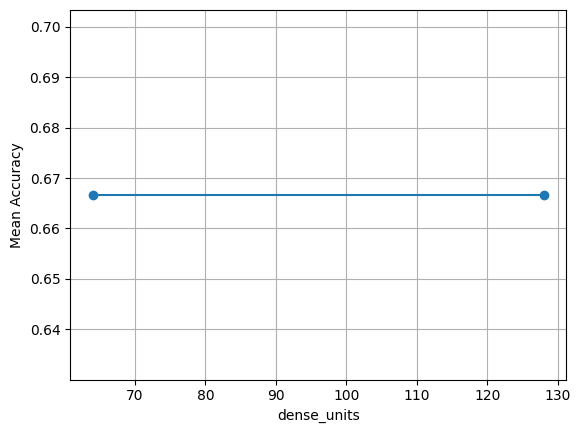

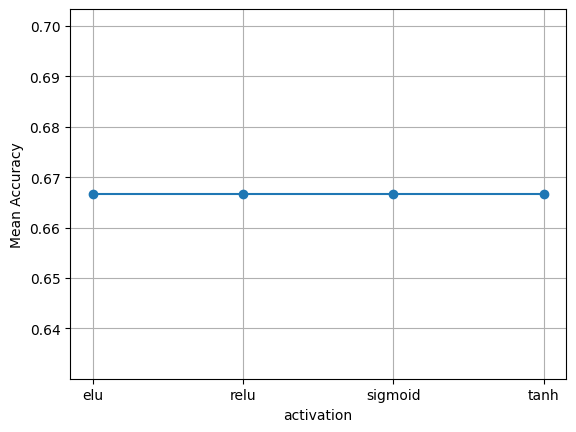

In [3]:
from sklearn.metrics import accuracy_score, classification_report

#Let's tune hyperparameters
def build_tensor_shallow_model(hp):
    dense_units = hp.Choice("dense_units", [64, 128]) # for feature classification 
    activeFunctions = hp.Choice("activation", ["relu", "sigmoid", "tanh", "elu"])
    model = keras.models.Sequential([
        layers.Input(shape=(224, 224, 3)),
        layers.Flatten(),
        layers.Dense(dense_units, activation=activeFunctions),
        layers.Dense(2)
    ])
    model.compile(optimizer='adam', loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True), metrics=['accuracy'])
    return model

model2Tuner = kt.GridSearch(
    build_tensor_shallow_model,
    objective="val_accuracy",
    max_trials=None,
    directory="fakeCardTensorflowLogs",
    project_name="pokemonFakeCardClassifierShallowModel"
)

model2Tuner.search(
    trainingImagesArray, trainingClassifyArray,
    epochs = 30,
    validation_data=(validationImagesArray, validationClassifyArray)
)

model2Results = pd.DataFrame([
    {**t.hyperparameters.values, "score": t.score} for t in model2Tuner.oracle.trials.values() if t.score is not None
])

model2 = model2Tuner.hypermodel.build(model2Tuner.get_best_hyperparameters(1)[0])

model2.fit(
    trainingImagesArray, trainingClassifyArray, 
    epochs = 30,
    validation_data=(validationImagesArray, validationClassifyArray)
)

model2.summary()
showHyperPlot("dense_units", model2Results, "score")
showHyperPlot("activation", model2Results, "score")

Test it on the test data we have set, then compare the two models. Pick the best one from here and export as a backend api

In [4]:
#prepare test set
testDF = pd.read_csv(f"{datasetPath}/test_labels.csv").sample(frac=1, random_state=42).reset_index(drop=True)
testImagesArray, testClassifyArray = processThroughImages(testDF["id"], testDF["label"], "test")
# test model 1
testCheck1 = np.argmax(model1.predict(testImagesArray), axis=1)
print(f"Model 1 accuracy: {accuracy_score(testClassifyArray, testCheck1)}")
print(classification_report(testClassifyArray, testCheck1, target_names=["Fake Cards", "Real Cards"]))
# test model 2
testCheck2 = np.argmax(model2.predict(testImagesArray), axis=1)
print(f"Model 2 accuracy: {accuracy_score(testClassifyArray, testCheck2)}")
print(classification_report(testClassifyArray, testCheck2, target_names=["Fake Cards", "Real Cards"]))





3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 485ms/step
Model 1 accuracy: 0.9487179487179487
              precision    recall  f1-score   support

  Fake Cards       0.90      0.96      0.93        28
  Real Cards       0.98      0.94      0.96        50

    accuracy                           0.95        78
   macro avg       0.94      0.95      0.95        78
weighted avg       0.95      0.95      0.95        78

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 273ms/step
Model 2 accuracy: 0.6282051282051282
              precision    recall  f1-score   support

  Fake Cards       0.00      0.00      0.00        28
  Real Cards       0.64      0.98      0.77        50

    accuracy                           0.63        78
   macro avg       0.32      0.49      0.39        78
weighted avg       0.41      0.63      0.49        78

